## COMPAS - 2 OBJECTIVES

### Multi Layer Perceptron

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** White and Non-white individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization_mlp import MLPScalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed=42
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(seed)

In [5]:
PREFIX_SAVE_IMAGE = 'images/2_objs_mlp'

In [6]:
data = pd.read_csv('dataset/compas_onerace.csv')
data = data.drop('Unnamed: 0', axis=1)

fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
objectives_names = ['White', 'Non-White']
results = {}

# Number of epochs
epochs = 200

In [8]:
# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

In [9]:
# Logistic Regression with equal weight to use as baseline model
equal = MLPScalarization(
                        num_objs=2,
                        X=X_train, 
                        y=y_train, 
                        fair_feat=fair_feature,
                        epochs=epochs,
                        lower_bound_estimate='lipschitz',  # Options: 'zero', 'lipschitz', or a float value
                    )
equal.optimize(np.array([1, 0]))

In [10]:
equal.objs

array([0.58257713, 0.64383622])

In [11]:
def machine_optimize(method, lb_estimate=0.01):
    w_scalar = MLPScalarization(
        num_objs=num_objs, 
        X=X_train, 
        y=y_train,
        fair_feat=fair_feature,
        epochs=epochs,
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    'moopt': moopt,
                    'objectives': objs,
                    'models': get_models(moopt),
                    'hypervolume': hypervolume_values
                }

In [12]:
def plot_frontier(method, color='#d73027'):
    title='Loss Trade-offs for White and Non-White Person'
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                #subset=equal.objs,
                color=color,
                fontsize=26,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

In [13]:
import matplotlib.pyplot as plt
def plot_opt_weights(method):

    pareto_models = results[method]['models']
    weights = np.array([sol.w for sol in results[method]['moopt'].solutions_list])

    plt.figure(figsize=(8,6))
    plt.scatter(weights[:, 0], weights[:, 1], c='b', alpha=0.7)
    plt.xlabel('Weight 1')
    plt.ylabel('Weight 2')
    plt.title(f'Pareto Frontier Weights ({method.upper()})')
    plt.grid(True)
    plt.show()

### MOLA

In [14]:
np.linalg.norm(equal.w@np.array(equal.gradient))**2/(equal.w@equal.L)

np.float64(0.00021522202222016792)

In [15]:
method = 'mola'
machine_optimize(method=method)

KeyboardInterrupt: 

<Figure size 1000x700 with 0 Axes>

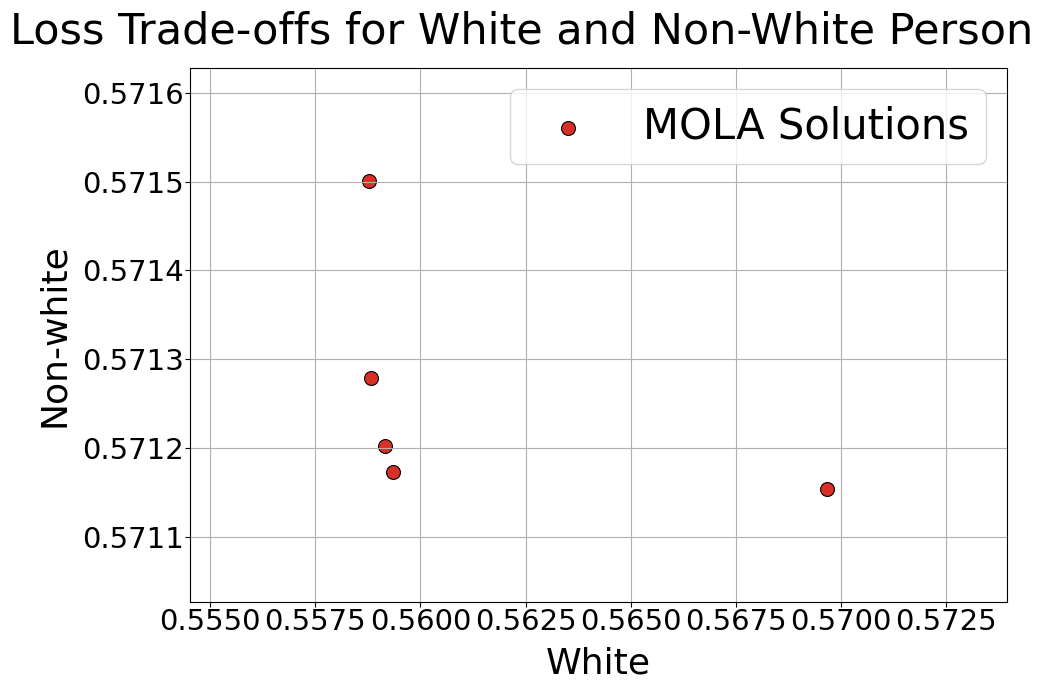

In [ ]:
plot_frontier('mola', color='#d73027')

In [ ]:
# Optimization Weights Analysis
# Descoment to show plot
#plot_opt_weights('mola')

### MOLA with gradient

In [ ]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

<Figure size 1000x700 with 0 Axes>

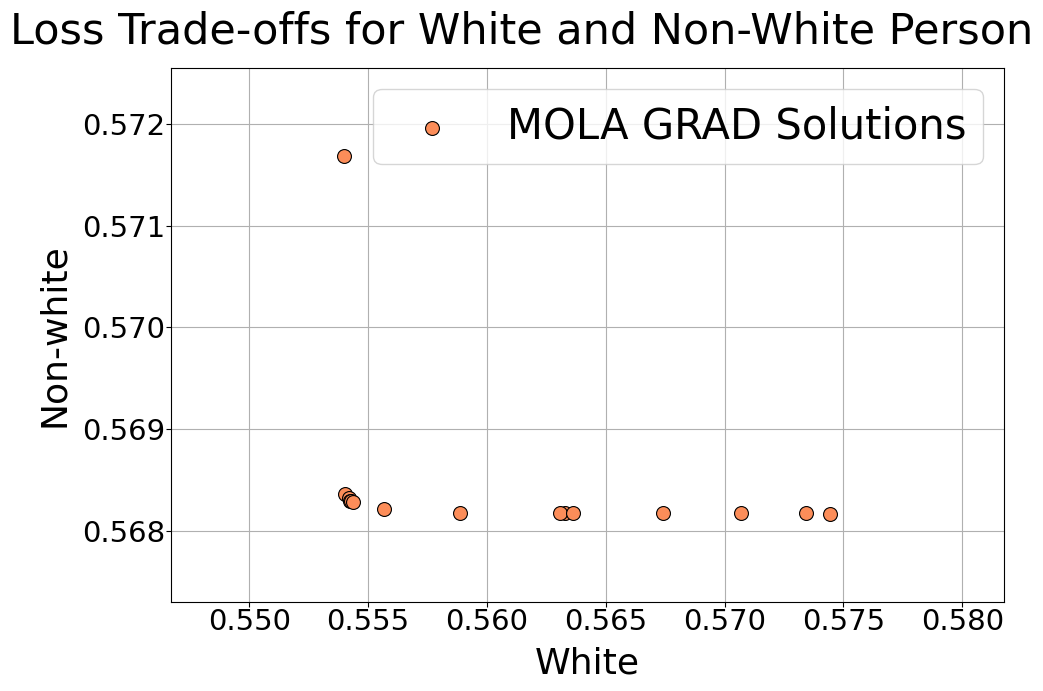

In [ ]:
plot_frontier(f'mola_grad', color='#fc8d59')

In [ ]:
# Optimization Weights Analysis
# Descoment to show plot
#plot_opt_weights('mola_grad')

### Random Weight

In [ ]:
method = 'random_weights'
machine_optimize(method=method)

In [ ]:
# plot_frontier(method, color='#4575b4')

In [ ]:
method = 'monise'
machine_optimize(method=method, lb_estimate='lipschitz')

### Non-dominated Solutions Analysis

In [ ]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weights']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

In [ ]:
print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 5
Number of non-dominated solutions with MOLA GRAD     : 15
Number of non-dominated solutions with RANDOM WEIGHT : 6


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

<Figure size 3000x700 with 0 Axes>

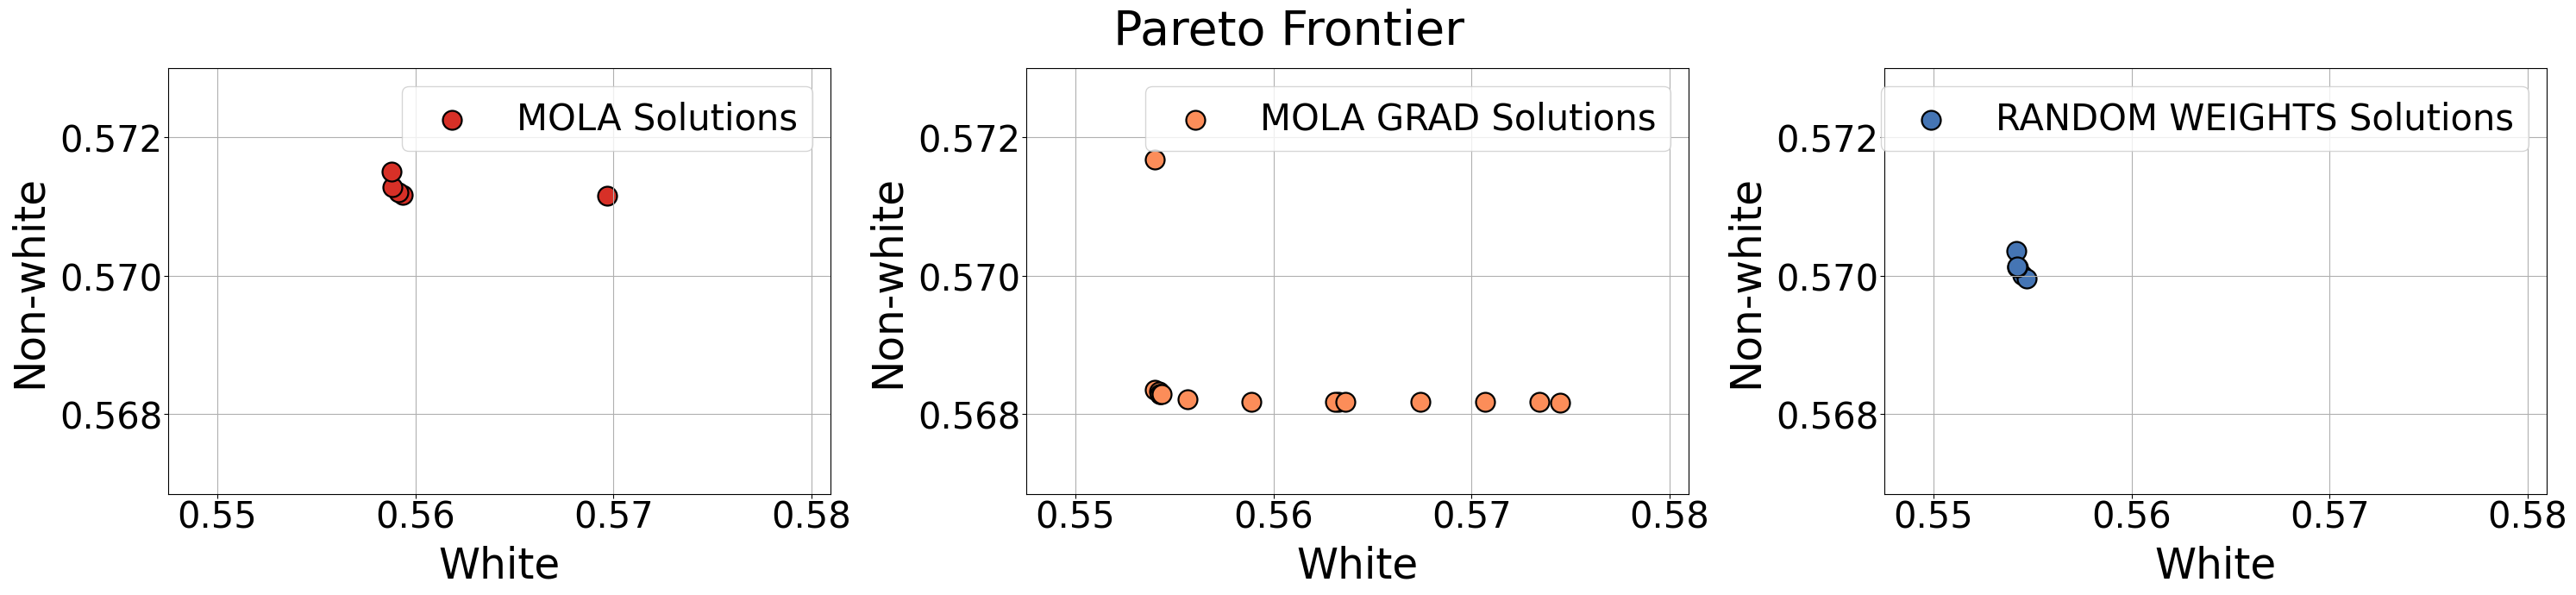

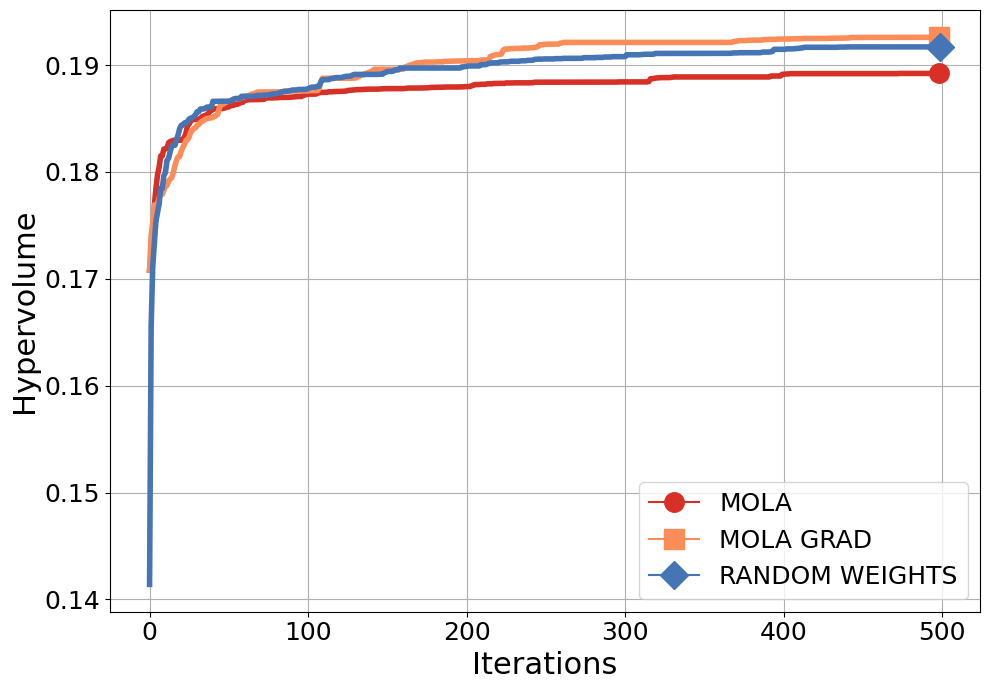

In [ ]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res and method != 'random_weights'
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=35,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf',
            s_factor = 5
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')